### Imports

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression , Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
import pickle


### Data Reading

In [2]:
df=pd.read_csv(r"D:\house_price_prediction\house_prices_practice.csv")
df.head()

,Id,OverallQual,GrLivArea,GarageCars,TotalBsmtSF,YearBuilt,FullBath,BedroomAbvGr,LotArea,SalePrice
0,1,7,1560,0,1658,1969,2,1,8059,177106
1,2,4,2827,2,1319,2012,3,4,13530,301044
2,3,8,3920,0,841,2010,1,4,9010,360609
3,4,5,3044,0,1058,1998,0,4,13207,240556
4,5,7,801,1,2428,2020,0,1,9117,193656


### Data preprocessing

In [3]:
df=df.rename(columns={"OverallQual":"quality","GrLivArea":"living_area","GarageCars":"garage_cars","GarageArea":"garage_area","TotalBsmtSF":"basement_area","FullBath":"full_bathrooms","TotRmsAbvGrd":"total_rooms"})


In [4]:
df.head()

,Id,quality,living_area,garage_cars,basement_area,YearBuilt,full_bathrooms,BedroomAbvGr,LotArea,SalePrice
0,1,7,1560,0,1658,1969,2,1,8059,177106
1,2,4,2827,2,1319,2012,3,4,13530,301044
2,3,8,3920,0,841,2010,1,4,9010,360609
3,4,5,3044,0,1058,1998,0,4,13207,240556
4,5,7,801,1,2428,2020,0,1,9117,193656


In [5]:
df.drop(columns=["Id"], inplace=True)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   quality         300 non-null    int64
 1   living_area     300 non-null    int64
 2   garage_cars     300 non-null    int64
 3   basement_area   300 non-null    int64
 4   YearBuilt       300 non-null    int64
 5   full_bathrooms  300 non-null    int64
 6   BedroomAbvGr    300 non-null    int64
 7   LotArea         300 non-null    int64
 8   SalePrice       300 non-null    int64
dtypes: int64(9)
memory usage: 21.2 KB


In [7]:
null_counts = df.isnull().sum()
nulls_ratio = null_counts / len(df)
nulls_df = pd.DataFrame({'Null Count': null_counts, 'Null Ratio': nulls_ratio})
print(nulls_df.T)

            quality  living_area  garage_cars  basement_area  YearBuilt  \
Null Count      0.0          0.0          0.0            0.0        0.0   
Null Ratio      0.0          0.0          0.0            0.0        0.0   

            full_bathrooms  BedroomAbvGr  LotArea  SalePrice  
Null Count             0.0           0.0      0.0        0.0  
Null Ratio             0.0           0.0      0.0        0.0  


In [8]:
df.describe()

,quality,living_area,garage_cars,basement_area,YearBuilt,full_bathrooms,BedroomAbvGr,LotArea,SalePrice
count,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000,300.000000
mean,5.326667,2307.386667,1.330000,1468.796667,1986.163333,1.523333,2.926667,8969.453333,252262.903333
std,2.873001,1042.561303,1.109898,672.333705,21.377089,1.131543,1.456604,3753.531132,74998.055214
min,1.000000,504.000000,0.000000,303.000000,1950.000000,0.000000,1.000000,2009.000000,82494.000000
25%,3.000000,1392.250000,0.000000,903.000000,1967.000000,0.000000,2.000000,5996.250000,190355.250000
50%,5.000000,2265.500000,1.000000,1502.000000,1986.000000,2.000000,3.000000,9031.000000,251292.500000
75%,8.000000,3306.500000,2.000000,2129.500000,2004.250000,3.000000,4.000000,12316.000000,307105.000000
max,10.000000,3998.000000,3.000000,2492.000000,2023.000000,3.000000,5.000000,14987.000000,435291.000000


### Outliers Check

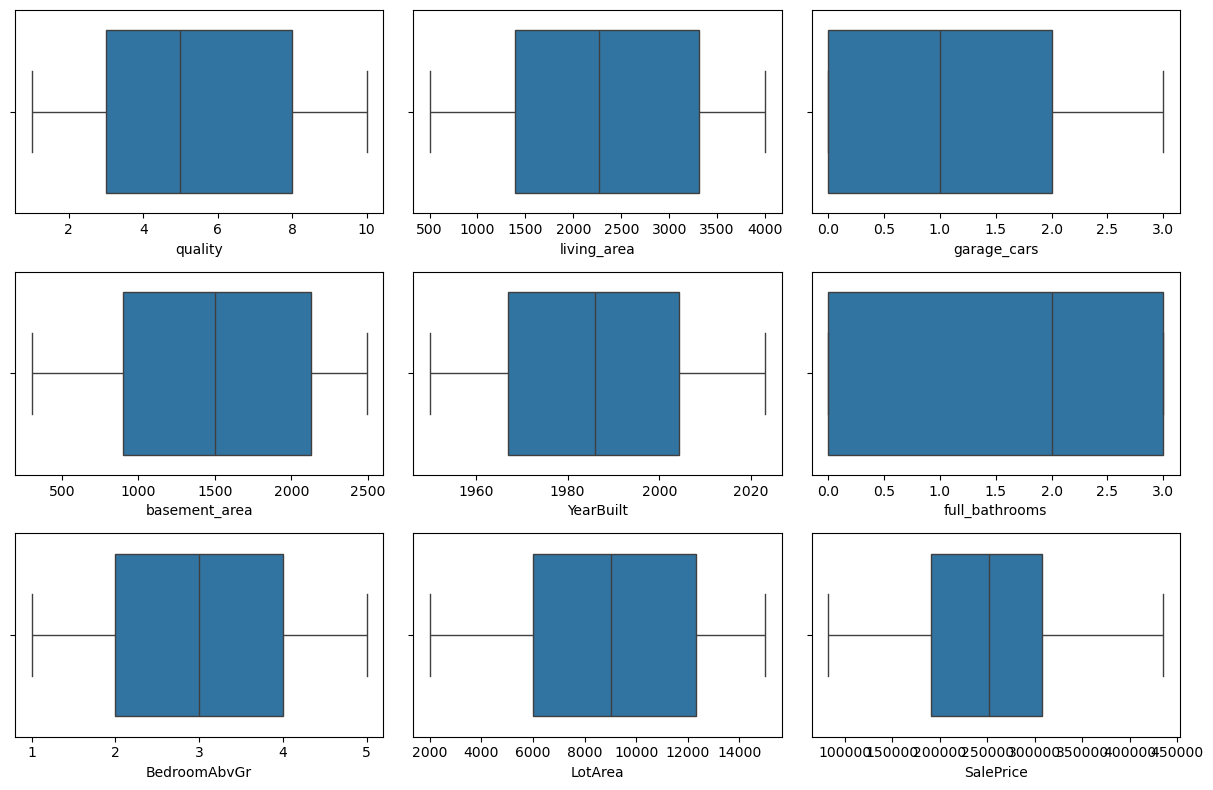

In [9]:
cols=df.columns
plt.figure(figsize=(12,8))
for i, col in enumerate(cols):
    plt.subplot(3,3,i+1)
    sns.boxplot(x=df[col])
plt.tight_layout()
plt.show()



### Correlation Matrix

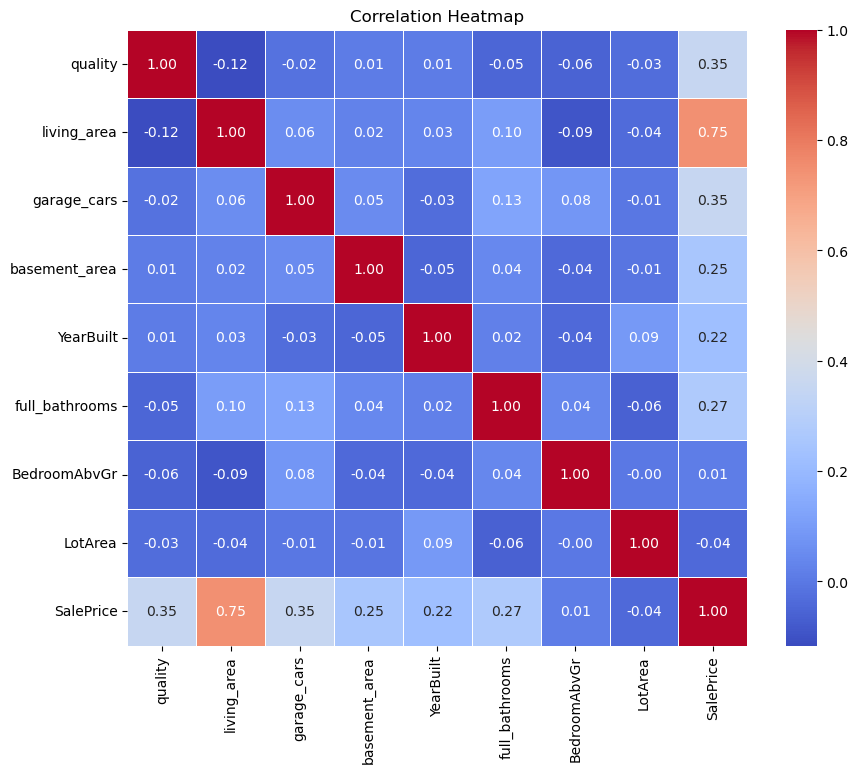

In [10]:
corr=df.corr()
plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

### Handle Date

In [11]:
df['Age_of_House'] = 2026 - df['YearBuilt']
df.drop(columns=['YearBuilt'], inplace=True)

In [12]:
df.head()

,quality,living_area,garage_cars,basement_area,full_bathrooms,BedroomAbvGr,LotArea,SalePrice,Age_of_House
0,7,1560,0,1658,2,1,8059,177106,57
1,4,2827,2,1319,3,4,13530,301044,14
2,8,3920,0,841,1,4,9010,360609,16
3,5,3044,0,1058,0,4,13207,240556,28
4,7,801,1,2428,0,1,9117,193656,6


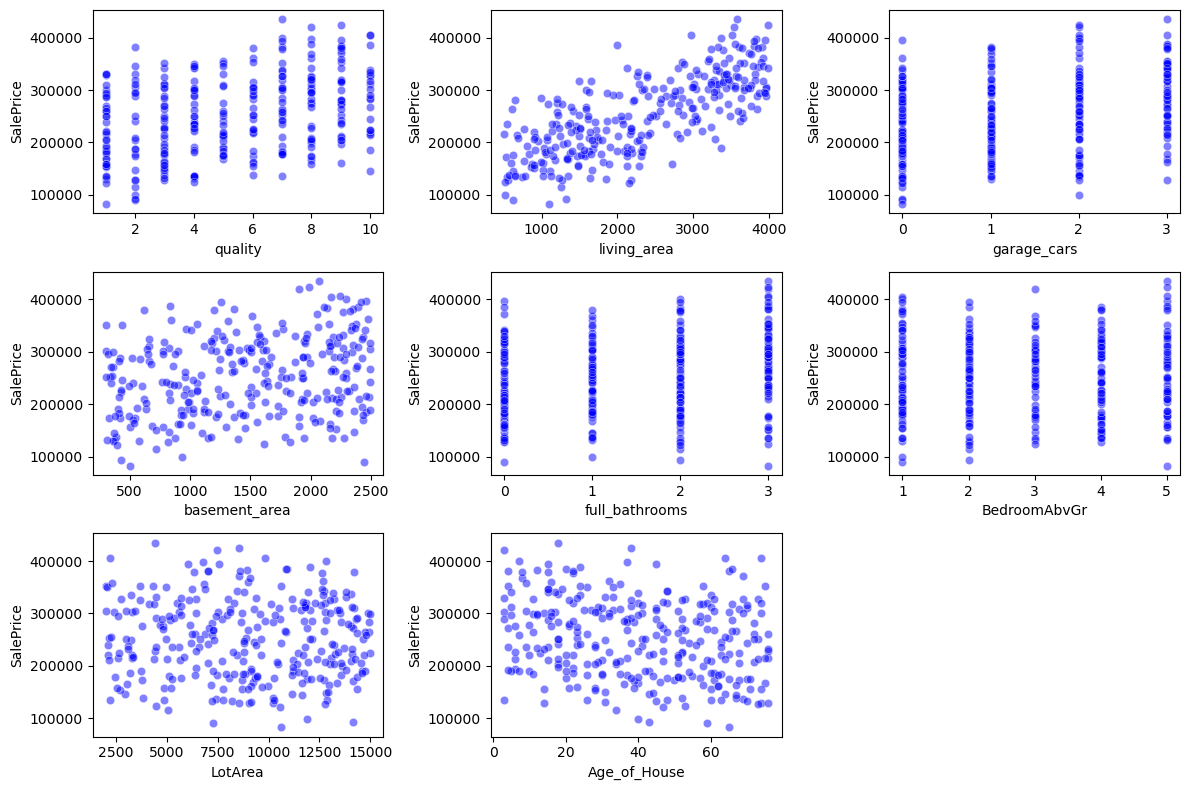

In [13]:
features=['quality', 'living_area', 'garage_cars', 'basement_area', 'full_bathrooms', 'BedroomAbvGr', 'LotArea', 'Age_of_House']
target='SalePrice'
plt.figure(figsize=(12,8))
for i, col in enumerate(features):
    plt.subplot(3,3,i+1)
    sns.scatterplot(x=df[col], y=df[target], alpha=0.5, color='blue')
plt.tight_layout()
plt.show()

In [14]:
X = df.drop(columns=['SalePrice'])
y = df['SalePrice']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
model = LinearRegression()
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print(f"Mean Squared Error: {mse:.2f}")
print(f"R^2 Score: {r2:.2f}")


Mean Squared Error: 156386511.42
R^2 Score: 0.97


In [15]:
from sklearn.pipeline import make_pipeline

pipe_line = make_pipeline(PolynomialFeatures(degree=2), StandardScaler(), LinearRegression())
pipe_line.fit(X_train, y_train)
y_pred_poly = pipe_line.predict(X_test)
mse_poly = mean_squared_error(y_test, y_pred_poly)
r2_poly = r2_score(y_test, y_pred_poly)
print(f"Polynomial Mean Squared Error: {mse_poly:.2f}")
print(f"Polynomial R^2 Score: {r2_poly:.2f}")


Polynomial Mean Squared Error: 158493898.75
Polynomial R^2 Score: 0.97


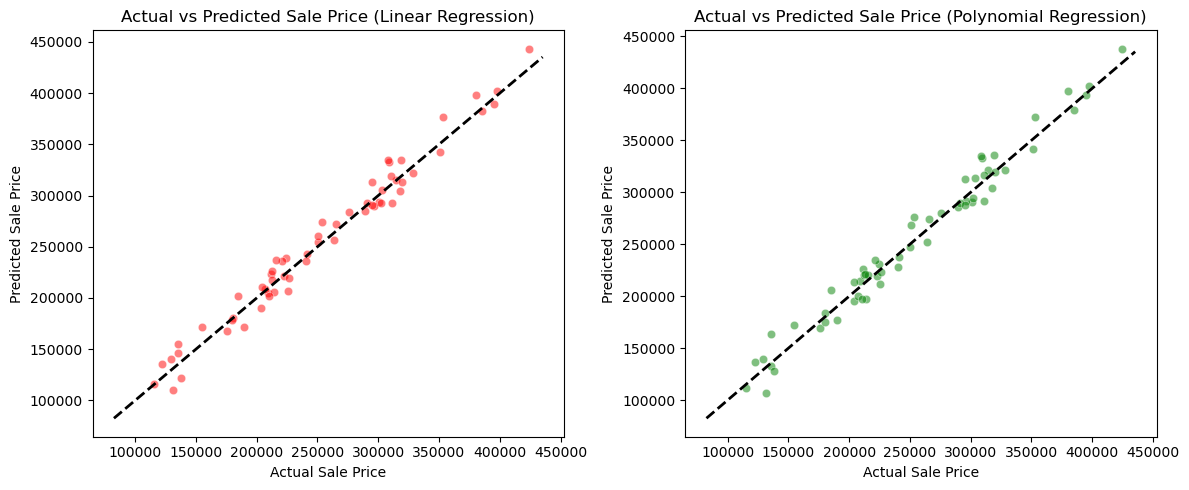

In [16]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.scatterplot(x=y_test, y=y_pred, alpha=0.5, color='red')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
plt.xlabel('Actual Sale Price')
plt.ylabel('Predicted Sale Price')
plt.title('Actual vs Predicted Sale Price (Linear Regression)')
plt.subplot(1,2,2)
sns.scatterplot(x=y_test, y=y_pred_poly, alpha=0.5, color='green')
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'k--', lw=2)
plt.xlabel('Actual Sale Price')
plt.ylabel('Predicted Sale Price')
plt.title('Actual vs Predicted Sale Price (Polynomial Regression)')
plt.tight_layout()
plt.show()


In [17]:
with open('house_price_model.pkl', 'wb') as f:
    pickle.dump(pipe_line, f)